# Factor Return Construction and Overlap Analysis

This notebook builds intuitive macro factor returns from `Data/1.cleaned_return_df.csv`, standardizes them, checks overlap through correlation/covariance analysis, and creates orthogonalized factors only as robustness checks.

Primary regime model input: raw standardized factor returns.
Robustness-only inputs: residual-orthogonalized and PCA-orthogonalized factors.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_FILE = PROJECT_ROOT / 'Data' / '1.cleaned_return_df.csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'factor_overlap'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ROLLING_WINDOW = 252
sns.set_theme(style='whitegrid')


## 1. Define Factor Clusters

The grouping below follows the intuitive buckets discussed earlier. Some columns naturally overlap, especially global aggregate bonds and ex-US equity, but they are kept where they are economically useful.


In [3]:
factor_clusters = {
    'Equity': [
        'dm_stock', 'MSCI World Gross', 'MSCI World', 'MSCI World Value',
        'MSCI_All Country World', 'MSCI World Real Estate', 'SNP global infrastructure',
    ],
    'Interest_Rate': [
        'fixed_income', 'Bloomberg Barclays Global AGG', 'Bloomberg Barclays US AGG',
        'Bloomberg Barclays US 1-3 month treasury', 'Bloomberg US 20+ Treasury',
        'Bloomberg US 7-10 Treasury', 'ICE US 20+ TREASURY', 'ICE US 7-10  TREASURY',
    ],
    'Credit': [
        'Bloomberg Barclays US ABS', 'Bloomberg Barclays US Corp HY',
        'Bloomberg Barclays US Corp IG', 'Bloomberg Barclays US Long Gov credit',
    ],
    'Commodities': [
        'commodity', 'SNP GSCI TR', 'SNP metal and mining',
        'SNP oil gas exploration and production',
    ],
    'Emerging_Market': ['em_stock', 'MSCI Emerging', 'Bloomberg Barclays EM AGG'],
    'Foreign_Currency': ['MSCI World x US', 'Bloomberg Barclays Global AGG'],
    'Local_Inflation': [
        'Bloomberg Barclays US Inflation Protected',
        'Bloomberg Barclays US Inflation Protected 7-10 year',
    ],
    'Local_Equity': ['Russel 300 TR'],
}

cluster_table = pd.DataFrame(
    [{'Factor': factor, 'Column': column} for factor, columns in factor_clusters.items() for column in columns]
)
cluster_table


,Factor,Column
0,Equity,dm_stock
1,Equity,MSCI World Gross
2,Equity,MSCI World
3,Equity,MSCI World Value
4,Equity,MSCI_All Country World
5,Equity,MSCI World Real Estate
6,Equity,SNP global infrastructure
7,Interest_Rate,fixed_income
8,Interest_Rate,Bloomberg Barclays Global AGG
9,Interest_Rate,Bloomberg Barclays US AGG


## 2. Load Data and Build Factor Returns

The file appears to already contain daily returns. The guard below only converts to log returns if the data looks like price levels rather than returns.


In [4]:
raw_data = pd.read_csv(DATA_FILE, parse_dates=['Date']).set_index('Date').sort_index()
numeric_data = raw_data.apply(pd.to_numeric, errors='coerce')

if numeric_data.abs().max(skipna=True).max() > 2:
    asset_returns = np.log(numeric_data / numeric_data.shift(1)).replace([np.inf, -np.inf], np.nan)
else:
    asset_returns = numeric_data.copy()

asset_returns.describe().T[['count', 'mean', 'std', 'min', 'max']].round(6)


,count,mean,std,min,max
dm_stock,10924.0,0.000193,0.007938,-0.099151,0.095229
em_stock,10924.0,0.000179,0.009473,-0.095115,0.105980
fixed_income,10924.0,0.000133,0.002711,-0.022421,0.047380
commodity,10924.0,0.000083,0.011161,-0.117701,0.079142
Bloomberg Barclays EM AGG,10528.0,0.000249,0.004387,-0.079447,0.100498
Bloomberg Barclays Global AGG,10923.0,0.000133,0.002711,-0.022421,0.047380
Bloomberg Barclays US 1-3 month treasury,10923.0,0.000101,0.000822,-0.006704,0.017317
Bloomberg Barclays US ABS,10923.0,0.000122,0.001536,-0.055432,0.025409
Bloomberg Barclays US AGG,10923.0,0.000143,0.001988,-0.020654,0.013346
Bloomberg Barclays US Corp HY,10923.0,0.000207,0.002621,-0.052910,0.035225


In [5]:
equal_weighted = pd.DataFrame(index=asset_returns.index)
inverse_vol_weighted = pd.DataFrame(index=asset_returns.index)
members_used = []

for factor, columns in factor_clusters.items():
    available = [column for column in columns if column in asset_returns.columns]
    factor_data = asset_returns[available]
    equal_weighted[factor] = factor_data.mean(axis=1, skipna=True)

    rolling_vol = factor_data.rolling(ROLLING_WINDOW, min_periods=50).std()
    inv_vol_weights = (1 / rolling_vol).replace([np.inf, -np.inf], np.nan)
    inv_vol_weights = inv_vol_weights.div(inv_vol_weights.sum(axis=1), axis=0)
    inverse_vol_weighted[factor] = (factor_data * inv_vol_weights).sum(axis=1, min_count=1)

    members_used.extend({'Factor': factor, 'Column': column} for column in available)

equal_weighted = equal_weighted.dropna(how='any')
inverse_vol_weighted = inverse_vol_weighted.reindex(equal_weighted.index).dropna(how='any')

# pd.DataFrame(members_used).to_csv(OUTPUT_DIR / 'factor_cluster_members.csv', index=False)
# equal_weighted.to_csv(OUTPUT_DIR / 'factor_returns_equal_weighted.csv')
# inverse_vol_weighted.to_csv(OUTPUT_DIR / 'factor_returns_inverse_vol_weighted.csv')

display(equal_weighted.tail())
display(inverse_vol_weighted.tail())


,Equity,Interest_Rate,Credit,Commodities,Emerging_Market,Foreign_Currency,Local_Inflation,Local_Equity
Date,,,,,,,,
2021-11-22,-0.005277,-0.007039,-0.004604,0.011730,-0.005037,-0.006494,-0.008512,-0.004631
2021-11-23,0.000631,-0.005223,-0.005810,0.018745,-0.005260,-0.005058,-0.004248,0.000501
2021-11-24,0.002084,0.003484,0.003234,0.002677,-0.000965,-0.003431,0.003762,0.002892
2021-11-25,0.001224,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2021-11-26,-0.010202,0.009653,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


,Equity,Interest_Rate,Credit,Commodities,Emerging_Market,Foreign_Currency,Local_Inflation,Local_Equity
Date,,,,,,,,
2021-11-22,-0.005056,-0.003629,-0.002256,0.010314,-0.003839,-0.006098,-0.008471,-0.004631
2021-11-23,0.000801,-0.001946,-0.002025,0.017245,-0.005695,-0.004306,-0.004238,0.000501
2021-11-24,0.002016,0.000494,0.000201,0.001810,0.000002,-0.002547,0.003765,0.002892
2021-11-25,0.001257,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2021-11-26,-0.010243,0.002720,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## 3. Standardize Factor Returns

These raw standardized factor returns are the primary regime model input.


In [ ]:
standardized_equal = (equal_weighted - equal_weighted.mean()) / equal_weighted.std(ddof=1)
standardized_inverse_vol = (inverse_vol_weighted - inverse_vol_weighted.mean()) / inverse_vol_weighted.std(ddof=1)

# standardized_equal.to_csv(OUTPUT_DIR / 'factor_returns_equal_weighted_standardized.csv')
# standardized_inverse_vol.to_csv(OUTPUT_DIR / 'factor_returns_inverse_vol_weighted_standardized.csv')

standardized_equal.describe().T[['mean', 'std', 'min', 'max']].round(4)


,mean,std,min,max
Equity,0.0,1.0,-12.6219,11.2491
Interest_Rate,-0.0,1.0,-9.9430,7.9486
Credit,0.0,1.0,-15.0794,7.1054
Commodities,-0.0,1.0,-12.3163,9.6620
Emerging_Market,-0.0,1.0,-9.9600,10.5685
Foreign_Currency,0.0,1.0,-12.4134,11.7971
Local_Inflation,0.0,1.0,-10.7998,13.5127
Local_Equity,0.0,1.0,-11.9396,11.0706


## 4. Correlation and Covariance Analysis

This section measures how much overlap exists between the raw standardized factors before any orthogonalization.


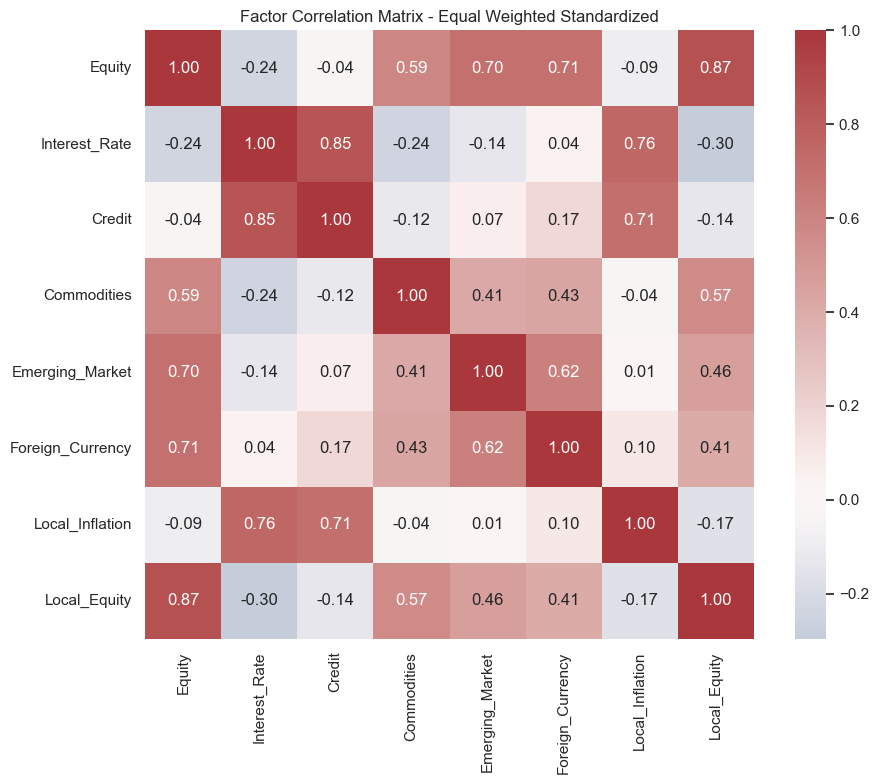

In [ ]:
correlation_matrix = standardized_equal.corr()
covariance_matrix = standardized_equal.cov()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(covariance_matrix, annot=True, fmt='.2f', cmap='vlag', center=0, square=True, ax=ax)
ax.set_title('Factor Covariance Matrix - Equal Weighted Standardized')
fig.tight_layout()
# fig.savefig(OUTPUT_DIR / 'covariance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Orthogonalization Robustness Tests Only

Do not use these as the primary regime model input. They are diagnostics for checking whether regime results survive when overlapping factor exposure is removed.


### Residual Orthogonalization

Each factor is regressed on the factors that come before it in the chosen order. The residual becomes the orthogonalized version of that factor. The order therefore matters and should reflect your intended economic hierarchy.


In [14]:
residual_orthogonalized = pd.DataFrame(index=standardized_equal.index)

for column in standardized_equal.columns:
    previous_columns = residual_orthogonalized.columns.tolist()
    if not previous_columns:
        residual_orthogonalized[column] = standardized_equal[column]
        continue

    aligned = pd.concat([standardized_equal[column], standardized_equal[previous_columns]], axis=1).dropna()
    y = aligned[column].to_numpy()
    x = np.column_stack([np.ones(len(aligned)), aligned[previous_columns].to_numpy()])
    beta = np.linalg.lstsq(x, y, rcond=None)[0]
    residual_orthogonalized.loc[aligned.index, column] = y - x @ beta

residual_orthogonalized = residual_orthogonalized.dropna()
# residual_orthogonalized.to_csv(OUTPUT_DIR / 'orthogonalized_residual_factors.csv')
# residual_orthogonalized.corr().to_csv(OUTPUT_DIR / 'orthogonalized_residual_correlation_matrix.csv')

residual_orthogonalized.corr().round(3)


,Equity,Interest_Rate,Credit,Commodities,Emerging_Market,Foreign_Currency,Local_Inflation,Local_Equity
Equity,1.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0
Interest_Rate,0.0,1.0,0.0,-0.0,0.0,0.0,-0.0,0.0
Credit,-0.0,0.0,1.0,-0.0,-0.0,0.0,0.0,-0.0
Commodities,-0.0,-0.0,-0.0,1.0,0.0,0.0,0.0,-0.0
Emerging_Market,-0.0,0.0,-0.0,0.0,1.0,0.0,-0.0,0.0
Foreign_Currency,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.0
Local_Inflation,0.0,-0.0,0.0,0.0,-0.0,0.0,1.0,0.0
Local_Equity,-0.0,0.0,-0.0,-0.0,0.0,-0.0,0.0,1.0


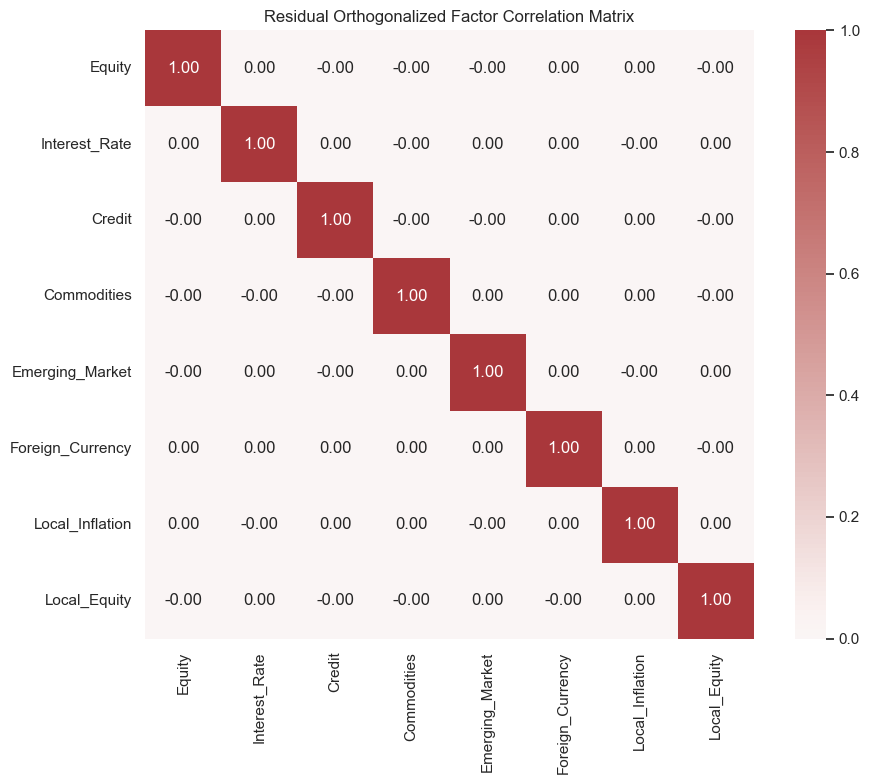

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(residual_orthogonalized.corr(), annot=True, fmt='.2f', cmap='vlag', center=0, square=True, ax=ax)
ax.set_title('Residual Orthogonalized Factor Correlation Matrix')
fig.tight_layout()
# fig.savefig(OUTPUT_DIR / 'orthogonalized_residual_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
